In [3]:
# Colab-ready script / notebook (as a single .py) to extract MediaPipe keypoints + joint angles
# and save research-ready artifacts (npz, CSV, plots, templates).
#
# Save this file in your repo as: notebooks/01_extract_keypoints_angles_colab.py
# It is written with "cells" separated by comments so you can paste into Colab cells,
# or run as a script locally after installing the dependencies.

# -----------------------------
# Cell 0 — Install dependencies (run in Colab)
# -----------------------------
# !pip install mediapipe opencv-python-headless matplotlib pandas numpy tqdm
# If using GPU Colab and you plan to use torch later, install torch separately.

# -----------------------------
# Cell 1 — Imports & config
# -----------------------------
import os
import sys
import time
import json
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# Try to import helper modules from src if present
try:
    from src.pose_estimator import MediapipeWrapper
    from src.angle_utils import compute_angles_from_keypoints
    print("Imported MediapipeWrapper and compute_angles_from_keypoints from src/")
    _HAVE_SRC = True
except Exception:
    _HAVE_SRC = False
    print("src.pose_estimator or src.angle_utils not found — using inline fallback implementations.")

# Fallback Mediapipe wrapper and simple angle computation
if not _HAVE_SRC:
    try:
        import mediapipe as mp
        _HAVE_MEDIAPIPE = True
    except Exception:
        _HAVE_MEDIAPIPE = False
        print("mediapipe not installed. Install with: pip install mediapipe")

    class MediapipeWrapper:
        def __init__(self, static_image_mode=True, model_complexity=1, min_detection_confidence=0.5):
            if not _HAVE_MEDIAPIPE:
                raise ImportError("mediapipe is required for MediapipeWrapper")
            self.mp = mp
            self.pose = mp.solutions.pose.Pose(static_image_mode=static_image_mode,
                                               model_complexity=model_complexity,
                                               min_detection_confidence=min_detection_confidence)

        def estimate(self, image_bgr):
            # image_bgr: HxWx3 BGR (OpenCV)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            results = self.pose.process(image_rgb)
            if results.pose_landmarks is None:
                return None, None
            lms = results.pose_landmarks.landmark
            arr = np.zeros((len(lms), 3), dtype=np.float32)
            conf = np.zeros((len(lms),), dtype=np.float32)
            h, w, _ = image_bgr.shape
            for i, lm in enumerate(lms):
                # convert to pixel coordinates
                arr[i, 0] = lm.x * w
                arr[i, 1] = lm.y * h
                arr[i, 2] = lm.z  # relative depth
                # Use visibility attribute if available, else 1
                conf[i] = getattr(lm, 'visibility', 1.0)
            return arr, conf

    def _angle_between(A, B, C, signed=False):
        # A, B, C: (x,y) or (x,y,z)
        v1 = A[:2] - B[:2]
        v2 = C[:2] - B[:2]
        n1 = np.linalg.norm(v1)
        n2 = np.linalg.norm(v2)
        if n1 == 0 or n2 == 0:
            return np.nan
        dot = np.dot(v1, v2) / (n1 * n2)
        dot = np.clip(dot, -1.0, 1.0)
        angle = np.degrees(np.arccos(dot))
        if signed:
            cross = v1[0]*v2[1] - v1[1]*v2[0]
            if cross < 0:
                angle = -angle
        return angle

    # MediaPipe pose landmark indices (BlazePose / MediaPipe Pose)
    _MP_IDX = {
        'nose': 0, 'left_shoulder': 11, 'right_shoulder': 12,
        'left_elbow': 13, 'right_elbow': 14, 'left_wrist': 15, 'right_wrist': 16,
        'left_hip': 23, 'right_hip': 24, 'left_knee': 25, 'right_knee': 26,
        'left_ankle': 27, 'right_ankle': 28,
        'left_eye': 1, 'right_eye': 2
    }

    def compute_angles_from_keypoints(kps):
        # kps: (N_landmarks, 3)
        # Returns a 1D numpy array of selected angles in degrees (order fixed)
        idx = _MP_IDX
        try:
            angles = []
            # elbow flexion
            angles.append(_angle_between(kps[idx['left_shoulder']], kps[idx['left_elbow']], kps[idx['left_wrist']]))
            angles.append(_angle_between(kps[idx['right_shoulder']], kps[idx['right_elbow']], kps[idx['right_wrist']]))
            # shoulder (arm relative to torso)
            angles.append(_angle_between(kps[idx['left_elbow']], kps[idx['left_shoulder']], kps[idx['left_hip']]))
            angles.append(_angle_between(kps[idx['right_elbow']], kps[idx['right_shoulder']], kps[idx['right_hip']]))
            # hip
            angles.append(_angle_between(kps[idx['left_shoulder']], kps[idx['left_hip']], kps[idx['left_knee']]))
            angles.append(_angle_between(kps[idx['right_shoulder']], kps[idx['right_hip']], kps[idx['right_knee']]))
            # knee
            angles.append(_angle_between(kps[idx['left_hip']], kps[idx['left_knee']], kps[idx['left_ankle']]))
            angles.append(_angle_between(kps[idx['right_hip']], kps[idx['right_knee']], kps[idx['right_ankle']]))
            # torso pitch: angle between vertical and hips->shoulders vector
            mid_hip = (kps[idx['left_hip']] + kps[idx['right_hip']]) / 2.0
            mid_sh = (kps[idx['left_shoulder']] + kps[idx['right_shoulder']]) / 2.0
            v = mid_sh[:2] - mid_hip[:2]
            # vertical vector (0, -1) assuming y downwards. compute angle from vertical
            vert = np.array([0.0, -1.0])
            n_v = np.linalg.norm(v)
            if n_v == 0:
                torso_angle = np.nan
            else:
                dot = np.dot(v, vert) / n_v
                dot = np.clip(dot, -1.0, 1.0)
                torso_angle = np.degrees(np.arccos(dot))
            angles.append(torso_angle)

            return np.array(angles, dtype=np.float32)
        except Exception:
            return None

# -----------------------------
# Cell 2 — Paths & settings
# -----------------------------
BASE_DIR = Path('../data')
SPLIT_DIR = BASE_DIR / 'split'   # we expect data/split/train and data/split/test
OUT_DIR = BASE_DIR / 'processed'
FIG_DIR = Path('reports') / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MIN_LANDMARK_CONF = 0.3   # average confidence threshold
SAVE_MAX_SAMPLES_PER_CLASS = None  # keep all by default
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# -----------------------------
# Cell 3 — Extraction function
# -----------------------------

def process_split(split_name='train'):
    split_path = SPLIT_DIR / split_name
    if not split_path.exists():
        raise FileNotFoundError(f"Split path not found: {split_path}")

    estimator = MediapipeWrapper(static_image_mode=True, min_detection_confidence=0.5)

    all_angles = []
    all_landmarks = []
    all_confs = []
    all_labels = []
    all_filenames = []

    class_counts = {}

    classes = sorted([d.name for d in split_path.iterdir() if d.is_dir()])
    for cls in classes:
        cls_dir = split_path / cls
        files = sorted([p for p in cls_dir.iterdir() if p.suffix.lower() in ['.jpg', '.jpeg', '.png']])
        if len(files) == 0:
            continue

        saved = 0
        for p in tqdm(files, desc=f"Processing {split_name}/{cls}"):
            img = cv2.imread(str(p))
            if img is None:
                continue
            kps, confs = estimator.estimate(img)
            if kps is None:
                continue
            # use mean confidence of required keypoints
            if confs.mean() < MIN_LANDMARK_CONF:
                continue
            angles = compute_angles_from_keypoints(kps)
            if angles is None or np.isnan(angles).any():
                continue

            all_angles.append(angles)
            all_landmarks.append(kps)
            all_confs.append(confs)
            all_labels.append(cls)
            # all_filenames.append(str(p.relative_to(Path.cwd())))
            all_filenames.append(str(p.resolve()))


            saved += 1
            if SAVE_MAX_SAMPLES_PER_CLASS is not None and saved >= SAVE_MAX_SAMPLES_PER_CLASS:
                break

        class_counts[cls] = saved

    # stack arrays
    if len(all_angles) == 0:
        raise RuntimeError(f"No valid samples found for split {split_name}")

    angles_arr = np.stack(all_angles)
    landmarks_arr = np.stack(all_landmarks)
    confs_arr = np.stack(all_confs)
    labels_arr = np.array(all_labels, dtype=object)
    files_arr = np.array(all_filenames, dtype=object)

    out_file = OUT_DIR / f"processed_{split_name}.npz"
    np.savez_compressed(str(out_file), angles=angles_arr, landmarks=landmarks_arr,
                        confidences=confs_arr, labels=labels_arr, filenames=files_arr)

    # save metadata CSV
    meta_df = pd.DataFrame({'filename': files_arr, 'label': labels_arr})
    meta_df['count'] = meta_df.groupby('label')['label'].transform('count')
    meta_csv = OUT_DIR / f"metadata_{split_name}.csv"
    meta_df.to_csv(meta_csv, index=False)

    # save class counts
    counts_csv = OUT_DIR / f"class_counts_{split_name}.csv"
    pd.Series(class_counts).to_csv(counts_csv, header=['count'])

    print(f"Saved processed split to: {out_file}")
    print(f"Saved metadata to: {meta_csv}")
    print(f"Saved class counts to: {counts_csv}")

    return {
        'angles': angles_arr,
        'landmarks': landmarks_arr,
        'confidences': confs_arr,
        'labels': labels_arr,
        'filenames': files_arr,
        'class_counts': class_counts,
        'meta_csv': str(meta_csv),
        'out_file': str(out_file)
    }

# -----------------------------
# Cell 4 — Run extraction for train + test (if available)
# -----------------------------
if __name__ == '__main__':
    start_time = time.time()
    results = {}
    for split in ['train', 'test']:
        split_path = SPLIT_DIR / split
        if split_path.exists():
            print(f"Starting extraction for split: {split}")
            results[split] = process_split(split)
        else:
            print(f"Split not found, skipping: {split}")

    # -----------------------------
    # Cell 5 — Compute templates (from train set) and save
    # -----------------------------
    if 'train' in results:
        train_angles = results['train']['angles']
        train_labels = results['train']['labels']
        classes = sorted(list(set(train_labels.tolist())))
        templates = {}
        for cls in classes:
            mask = (train_labels == cls)
            arr = train_angles[mask]
            # use robust mean: drop nan and compute mean/std
            arr = arr[~np.isnan(arr).any(axis=1)]
            if arr.shape[0] == 0:
                continue
            templates[cls] = {
                'mean': arr.mean(axis=0).astype(np.float32),
                'std': arr.std(axis=0).astype(np.float32),
                'n': int(arr.shape[0])
            }

        templates_out = OUT_DIR / 'templates_angles.npz'
        # convert to savable dict
        savez_dict = {}
        for cls, v in templates.items():
            savez_dict[f"{cls}_mean"] = v['mean']
            savez_dict[f"{cls}_std"] = v['std']
            savez_dict[f"{cls}_n"] = v['n']
        np.savez_compressed(str(templates_out), **savez_dict)
        print(f"Saved templates to: {templates_out}")

    # -----------------------------
    # Cell 6 — Plots & statistics (for paper)
    # -----------------------------
    # collect class counts across splits
    all_counts = {}
    for split, r in results.items():
        all_counts[split] = r['class_counts']

    # Merge counts into dataframe
    rows = []
    for split, cc in all_counts.items():
        for cls, cnt in cc.items():
            rows.append({'split': split, 'class': cls, 'count': cnt})
    df_counts = pd.DataFrame(rows)
    # pivot for plotting
    pivot = df_counts.pivot(index='class', columns='split', values='count').fillna(0)

    # Bar plot per-class (train vs test)
    plt.figure(figsize=(14,6))
    pivot.plot(kind='bar', figsize=(14,6))
    plt.title('Per-class sample counts (train vs test)')
    plt.tight_layout()
    fig_path = FIG_DIR / 'per_class_counts_train_test.png'
    plt.savefig(str(fig_path))
    plt.close()
    print(f"Saved figure: {fig_path}")

    # Histogram of class sizes (train)
    if 'train' in all_counts:
        counts = list(all_counts['train'].values())
        plt.figure(figsize=(8,5))
        plt.hist(counts, bins=[0,25,50,75,100,125,150,200,300], edgecolor='black')
        plt.xlabel('Number of images per class (train)')
        plt.ylabel('Number of classes')
        plt.title('Histogram: class sizes (train)')
        plt.tight_layout()
        hist_path = FIG_DIR / 'hist_class_sizes_train.png'
        plt.savefig(str(hist_path))
        plt.close()
        print(f"Saved figure: {hist_path}")

    # Boxplot
    if 'train' in all_counts:
        df_train = df_counts[df_counts['split'] == 'train']
        plt.figure(figsize=(6,5))
        plt.boxplot(df_train['count'].values, vert=True, patch_artist=True)
        plt.ylabel('Number of images per class (train)')
        plt.title('Boxplot of class sizes (train)')
        box_path = FIG_DIR / 'boxplot_class_sizes_train.png'
        plt.savefig(str(box_path))
        plt.close()
        print(f"Saved figure: {box_path}")

    # Save summary CSV
    summary_csv = OUT_DIR / 'dataset_summary.csv'
    df_counts.to_csv(summary_csv, index=False)
    print(f"Saved dataset summary to: {summary_csv}")

    # Save extraction log
    log = {
        'timestamp': time.asctime(),
        'script': 'notebooks/01_extract_keypoints_angles_colab.py',
        'random_seed': RANDOM_SEED
    }
    try:
        import mediapipe as mp
        log['mediapipe_version'] = mp.__version__
    except Exception:
        log['mediapipe_version'] = 'not_installed'

    log_path = OUT_DIR / 'extraction_log.json'
    with open(log_path, 'w') as f:
        json.dump(log, f, indent=2)
    print(f"Saved log to: {log_path}")

    elapsed = time.time() - start_time
    print(f"Done. Elapsed: {elapsed/60:.2f} minutes")

    # Final message
    print('\nArtifacts produced:')
    for p in OUT_DIR.iterdir():
        print(' -', p)
    for p in FIG_DIR.iterdir():
        print(' -', p)

    print('\nNext steps: run the baseline training notebook (XGBoost on angles) using the produced processed_train.npz and templates_angles.npz')


src.pose_estimator or src.angle_utils not found — using inline fallback implementations.
Starting extraction for split: train


Processing train/Akarna_Dhanurasana: 100%|██████████| 58/58 [00:04<00:00, 13.50it/s]
Processing train/Bharadvajas_Twist_pose_or_Bharadvajasana_I_: 100%|██████████| 55/55 [00:04<00:00, 13.49it/s]
Processing train/Boat_Pose_or_Paripurna_Navasana_: 100%|██████████| 120/120 [00:08<00:00, 14.58it/s]
Processing train/Bound_Angle_Pose_or_Baddha_Konasana_: 100%|██████████| 120/120 [00:08<00:00, 14.27it/s]
Processing train/Bow_Pose_or_Dhanurasana_: 100%|██████████| 120/120 [00:09<00:00, 13.29it/s]
Processing train/Bridge_Pose_or_Setu_Bandha_Sarvangasana_: 100%|██████████| 120/120 [00:08<00:00, 14.27it/s]
Processing train/Crane_(Crow)_Pose_or_Bakasana_: 100%|██████████| 120/120 [00:09<00:00, 13.27it/s]
Processing train/Dolphin_Pose_or_Ardha_Pincha_Mayurasana_: 100%|██████████| 48/48 [00:03<00:00, 15.20it/s]
Processing train/Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_: 100%|██████████| 110/110 [00:07<00:00, 13.88it/s]
Processing train/Eagle_Pose_or_Garudasana_: 100%|██████████| 87/87 [00:06

Saved processed split to: ..\data\processed\processed_train.npz
Saved metadata to: ..\data\processed\metadata_train.csv
Saved class counts to: ..\data\processed\class_counts_train.csv
Starting extraction for split: test


Processing test/Akarna_Dhanurasana: 100%|██████████| 15/15 [00:01<00:00, 13.34it/s]
Processing test/Bharadvajas_Twist_pose_or_Bharadvajasana_I_: 100%|██████████| 14/14 [00:00<00:00, 15.28it/s]
Processing test/Boat_Pose_or_Paripurna_Navasana_: 100%|██████████| 30/30 [00:01<00:00, 15.46it/s]
Processing test/Bound_Angle_Pose_or_Baddha_Konasana_: 100%|██████████| 30/30 [00:02<00:00, 13.92it/s]
Processing test/Bow_Pose_or_Dhanurasana_: 100%|██████████| 30/30 [00:02<00:00, 13.45it/s]
Processing test/Bridge_Pose_or_Setu_Bandha_Sarvangasana_: 100%|██████████| 30/30 [00:02<00:00, 12.79it/s]
Processing test/Crane_(Crow)_Pose_or_Bakasana_: 100%|██████████| 30/30 [00:01<00:00, 15.09it/s]
Processing test/Dolphin_Pose_or_Ardha_Pincha_Mayurasana_: 100%|██████████| 12/12 [00:00<00:00, 14.35it/s]
Processing test/Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_: 100%|██████████| 28/28 [00:01<00:00, 14.52it/s]
Processing test/Eagle_Pose_or_Garudasana_: 100%|██████████| 22/22 [00:01<00:00, 13.48it/s]
Pro

Saved processed split to: ..\data\processed\processed_test.npz
Saved metadata to: ..\data\processed\metadata_test.csv
Saved class counts to: ..\data\processed\class_counts_test.csv
Saved templates to: ..\data\processed\templates_angles.npz


C:\Users\Harsh\AppData\Local\Temp\ipykernel_8680\1784026378.py:317: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved figure: reports\figures\per_class_counts_train_test.png
Saved figure: reports\figures\hist_class_sizes_train.png
Saved figure: reports\figures\boxplot_class_sizes_train.png
Saved dataset summary to: ..\data\processed\dataset_summary.csv
Saved log to: ..\data\processed\extraction_log.json
Done. Elapsed: 13.53 minutes

Artifacts produced:
 - ..\data\processed\class_counts_test.csv
 - ..\data\processed\class_counts_train.csv
 - ..\data\processed\dataset_summary.csv
 - ..\data\processed\extraction_log.json
 - ..\data\processed\metadata_test.csv
 - ..\data\processed\metadata_train.csv
 - ..\data\processed\processed_test.npz
 - ..\data\processed\processed_train.npz
 - ..\data\processed\templates_angles.npz
 - reports\figures\boxplot_class_sizes_train.png
 - reports\figures\hist_class_sizes_train.png
 - reports\figures\per_class_counts_train_test.png

Next steps: run the baseline training notebook (XGBoost on angles) using the produced processed_train.npz and templates_angles.npz


<Figure size 1400x600 with 0 Axes>

Loaded ..\data\processed\processed_train.npz
Keys: ['angles', 'landmarks', 'confidences', 'labels', 'filenames']
Loaded ..\data\processed\processed_test.npz
Keys: ['angles', 'landmarks', 'confidences', 'labels', 'filenames']

Train data shapes:
Angles: (6888, 9)
Landmarks: (6888, 33, 3)
Labels: (6888,)

Test data shapes:
Angles: (1761, 9)
Landmarks: (1761, 33, 3)
Labels: (1761,)

Train metadata sample:
                                            filename               label  \
0  C:\Users\Harsh\Desktop\pro\data\split\train\Ak...  Akarna_Dhanurasana   
1  C:\Users\Harsh\Desktop\pro\data\split\train\Ak...  Akarna_Dhanurasana   
2  C:\Users\Harsh\Desktop\pro\data\split\train\Ak...  Akarna_Dhanurasana   
3  C:\Users\Harsh\Desktop\pro\data\split\train\Ak...  Akarna_Dhanurasana   
4  C:\Users\Harsh\Desktop\pro\data\split\train\Ak...  Akarna_Dhanurasana   

   count  
0     53  
1     53  
2     53  
3     53  
4     53  

Class distribution (train):
label
Supported_Headstand_pose_or_Salamba_

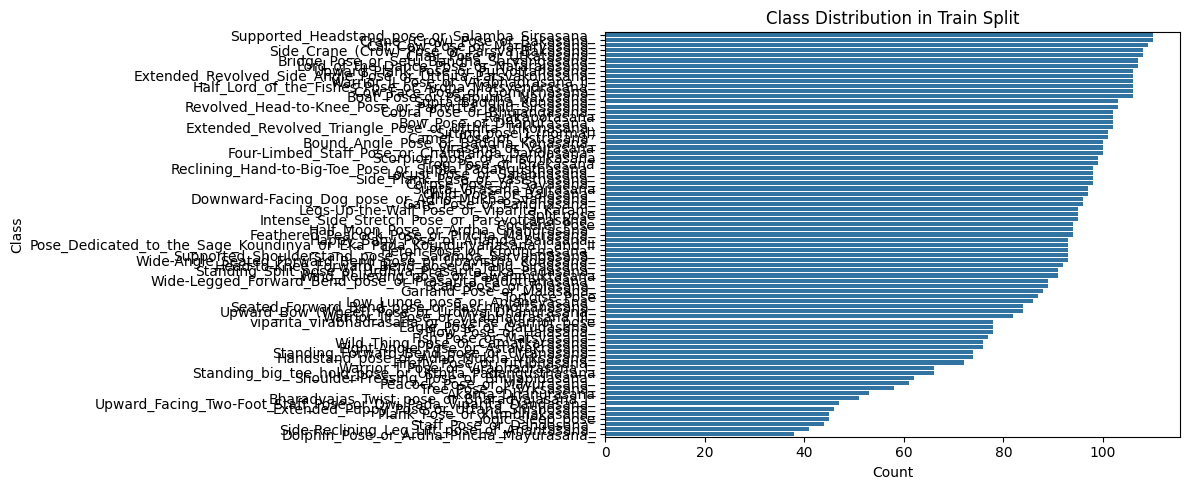


Example angle vector for sample 0 (len=9):
 [170.68814   31.149332 101.24109  107.40678   54.69669   51.769993
 165.89485   63.361053  23.45259 ]


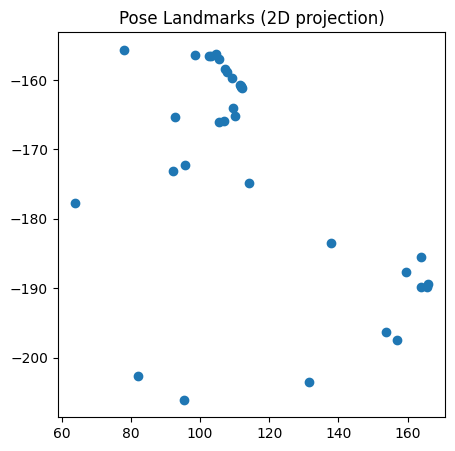

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Paths ---
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
test_file  = PROC_DIR / "processed_test.npz"

# --- Load NPZ ---
def load_npz(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    print(f"Loaded {npz_path}")
    print("Keys:", list(data.keys()))
    return data

train_npz = load_npz(train_file)
test_npz  = load_npz(test_file)

# --- Inspect shapes ---
print("\nTrain data shapes:")
print("Angles:", train_npz['angles'].shape)
print("Landmarks:", train_npz['landmarks'].shape)
print("Labels:", train_npz['labels'].shape)

print("\nTest data shapes:")
print("Angles:", test_npz['angles'].shape)
print("Landmarks:", test_npz['landmarks'].shape)
print("Labels:", test_npz['labels'].shape)

# --- Metadata ---
train_meta = pd.read_csv(PROC_DIR / "metadata_train.csv")
test_meta  = pd.read_csv(PROC_DIR / "metadata_test.csv")

print("\nTrain metadata sample:")
print(train_meta.head())

print("\nClass distribution (train):")
print(train_meta['label'].value_counts())

# --- Visualization ---
plt.figure(figsize=(12,5))
sns.countplot(data=train_meta, y="label", order=train_meta['label'].value_counts().index)
plt.title("Class Distribution in Train Split")
plt.xlabel("Count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

# --- Example: visualize first angle vector ---
sample_idx = 0
angles = train_npz['angles'][sample_idx]
print(f"\nExample angle vector for sample {sample_idx} (len={len(angles)}):\n", angles)

# --- Example: visualize landmarks as scatter ---
landmarks = train_npz['landmarks'][sample_idx].reshape(-1, 3)  # (33, 3) if MediaPipe
plt.figure(figsize=(5,5))
plt.scatter(landmarks[:,0], -landmarks[:,1])  # flip Y for visualization
plt.title("Pose Landmarks (2D projection)")
plt.show()


In [3]:
train_npz["angles"]

array([[170.68814 ,  31.149332, 101.24109 , ..., 165.89485 ,  63.361053,
         23.45259 ],
       [167.0401  ,  14.495199,  98.619705, ..., 156.95105 ,  51.137615,
         26.665237],
       [157.51782 ,  14.952825, 111.17452 , ..., 179.43907 ,  72.90276 ,
         38.865795],
       ...,
       [173.0763  , 176.71312 , 164.7936  , ..., 107.22809 , 174.83078 ,
         23.720945],
       [163.15265 , 173.51645 , 157.27548 , ..., 104.114235, 177.68776 ,
         31.14122 ],
       [169.63889 , 175.49371 , 174.96036 , ..., 115.46495 , 168.40964 ,
         24.801903]], dtype=float32)

In [9]:
train_npz["landmarks"][0]


array([[ 1.09654205e+02,  1.63971771e+02, -4.16146457e-01],
       [ 1.11423935e+02,  1.60749649e+02, -4.12177950e-01],
       [ 1.11840042e+02,  1.60939957e+02, -4.12145287e-01],
       [ 1.12211807e+02,  1.61086426e+02, -4.12341684e-01],
       [ 1.09204590e+02,  1.59772476e+02, -4.16243702e-01],
       [ 1.07876434e+02,  1.58894516e+02, -4.16282266e-01],
       [ 1.07145676e+02,  1.58416428e+02, -4.16207224e-01],
       [ 1.11851028e+02,  1.60921249e+02, -3.20875406e-01],
       [ 1.05384804e+02,  1.57036682e+02, -3.35854709e-01],
       [ 1.10237534e+02,  1.65124695e+02, -3.75265986e-01],
       [ 1.07006523e+02,  1.65891678e+02, -3.79924923e-01],
       [ 1.14250153e+02,  1.74848206e+02, -2.35033661e-01],
       [ 9.27596130e+01,  1.65293503e+02, -2.75484025e-01],
       [ 1.37974060e+02,  1.83533218e+02, -2.67379910e-01],
       [ 7.81400833e+01,  1.55636719e+02, -2.92206258e-01],
       [ 1.59676270e+02,  1.87671234e+02, -3.11715096e-01],
       [ 9.85042496e+01,  1.56453568e+02

In [ ]:
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"

# Load data
train_npz = np.load(train_file, allow_pickle=True)
angles = train_npz["angles"]
labels = train_npz["labels"]

# Pick a sample
idx = 0
sample_angles = angles[idx]
label = labels[idx]

# If you have a predefined list of names, check its length
ANGLE_NAMES = [
    "Neck Flexion", "Left Shoulder", "Right Shoulder",
    "Left Elbow", "Right Elbow", "Left Hip", "Right Hip",
    "Left Knee", "Right Knee", "Left Ankle", "Right Ankle",
    "Torso Pitch", "Torso Yaw"
]

# Ensure lengths match
if len(sample_angles) != len(ANGLE_NAMES):
    print(f"⚠️ Warning: {len(sample_angles)} angles found, "
          f"but {len(ANGLE_NAMES)} names defined.")
    # Auto-generate names instead
    ANGLE_NAMES = [f"Angle_{i}" for i in range(len(sample_angles))]

# Build table
df_angles = pd.DataFrame({
    "Joint": ANGLE_NAMES,
    "Angle (degrees)": np.round(sample_angles, 2)
})

print(f"Pose Class: {label}")
print(df_angles)

⚠️ Warning: 9 angles found, but 13 names defined.
Pose Class: Akarna_Dhanurasana
     Joint  Angle (degrees)
0  Angle_0       170.690002
1  Angle_1        31.150000
2  Angle_2       101.239998
3  Angle_3       107.410004
4  Angle_4        54.700001
5  Angle_5        51.770000
6  Angle_6       165.889999
7  Angle_7        63.360001
8  Angle_8        23.450001


In [16]:

train_file = PROC_DIR / "processed_train.npz"

train_npz = np.load(train_file, allow_pickle=True)
angles = train_npz["angles"]

print("Angle vector shape:", angles.shape)
print(f"✅ Each sample has {angles.shape[1]} angles.")


Angle vector shape: (6888, 9)
✅ Each sample has 9 angles.


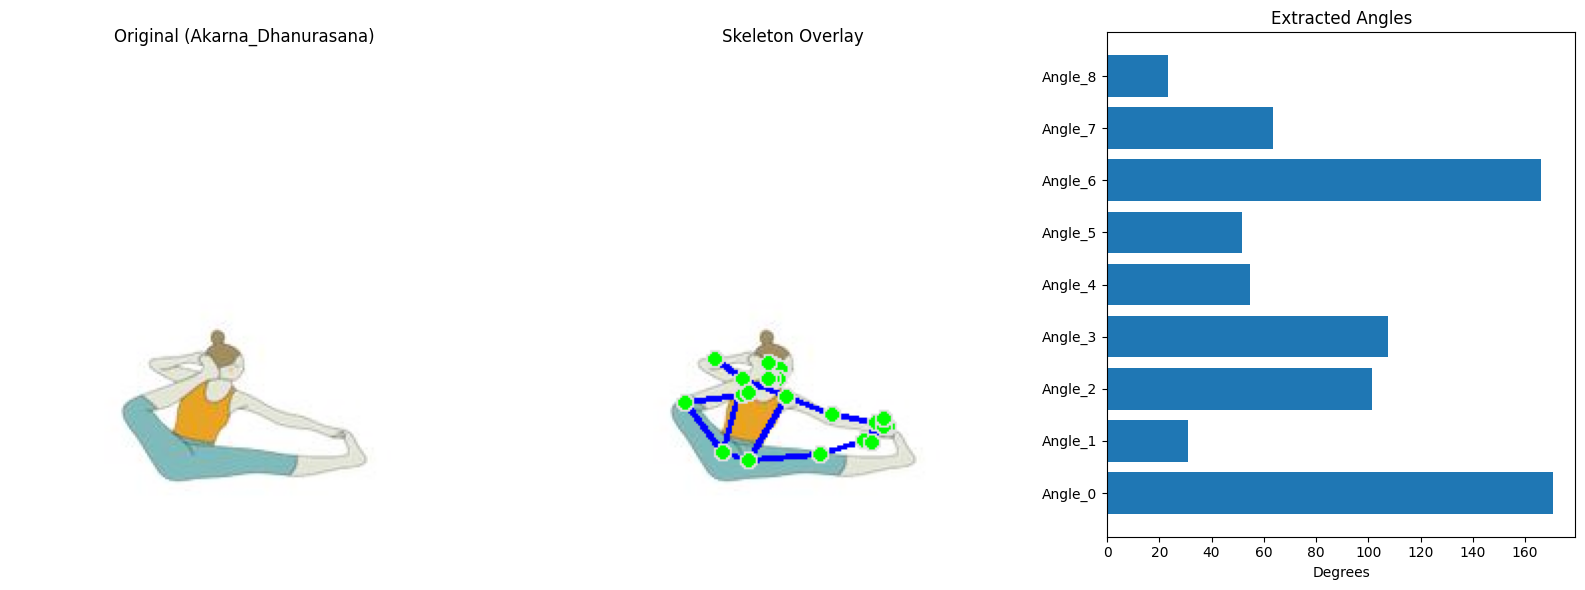

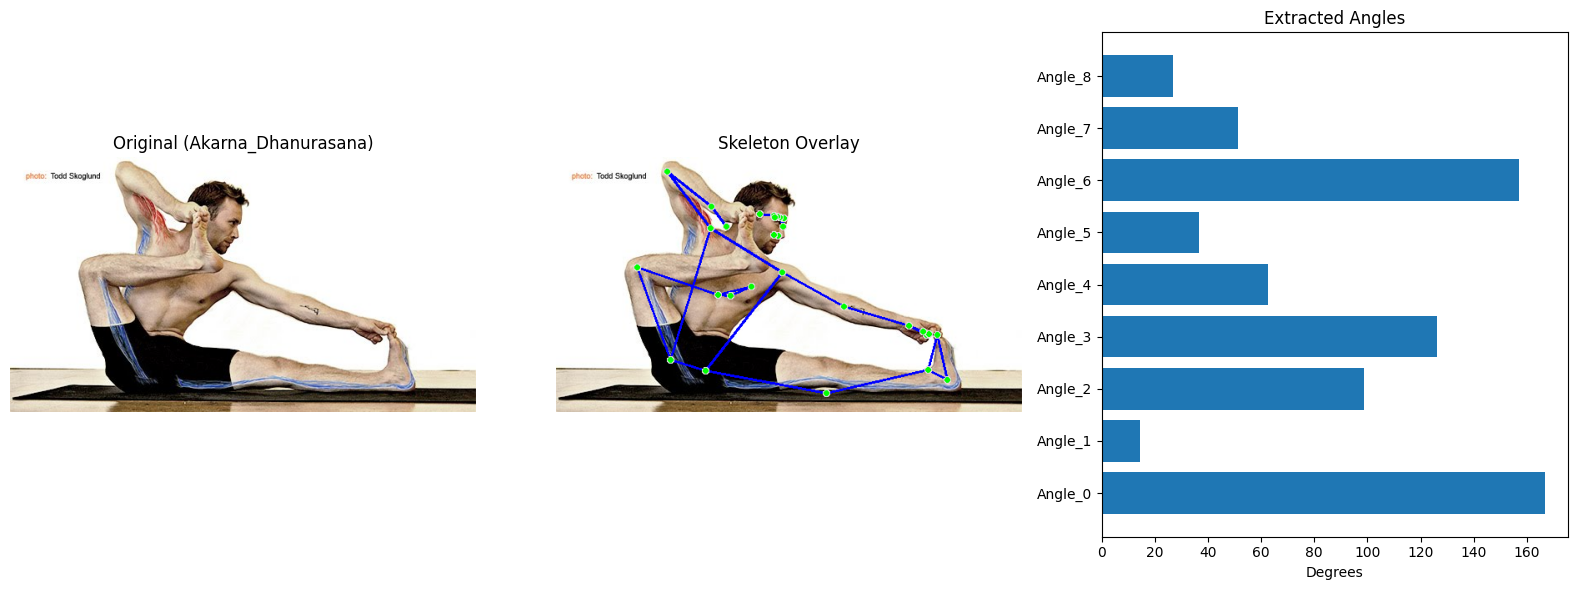

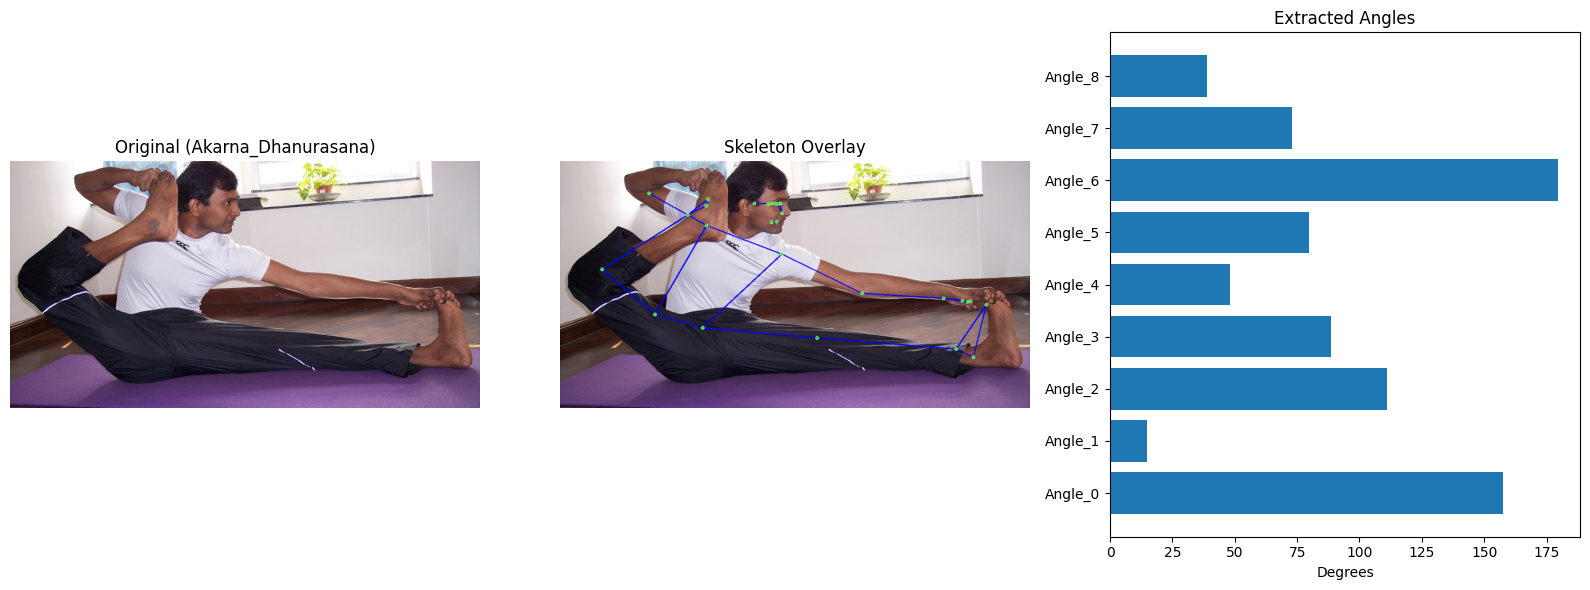

In [ ]:
import cv2
import matplotlib.pyplot as plt

# --- Load data ---
train_file = PROC_DIR / "processed_train.npz"
train_meta = pd.read_csv(PROC_DIR / "metadata_train.csv")

train_npz = np.load(train_file, allow_pickle=True)
angles = train_npz["angles"]
labels = train_npz["labels"]

# Mediapipe drawing utils
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def show_example(idx=0):
    row = train_meta.iloc[idx]
    img_path = Path(row["filename"])
    label = row["label"]

    # Load image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Pose estimation
    with mp_pose.Pose(static_image_mode=True) as pose:
        results = pose.process(img_rgb)
        annotated = img_rgb.copy()
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                annotated,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                connection_drawing_spec=mp_drawing.DrawingSpec(color=(0,0,255), thickness=2)
            )

    # Angle vector
    sample_angles = angles[idx]
    angle_names = [f"Angle_{i}" for i in range(len(sample_angles))]
    

    # Plot side by side
    fig, axes = plt.subplots(1,3, figsize=(16,6))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original ({label})")
    axes[0].axis("off")

    axes[1].imshow(annotated)
    axes[1].set_title("Skeleton Overlay")
    axes[1].axis("off")

    axes[2].barh(angle_names, sample_angles)
    axes[2].set_title("Extracted Angles")
    axes[2].set_xlabel("Degrees")

    plt.tight_layout()
    plt.show()

# Show a few examples
for idx in [0, 1, 2]:
    show_example(idx)


In [18]:
ANGLE_NAMES


['Angle_0',
 'Angle_1',
 'Angle_2',
 'Angle_3',
 'Angle_4',
 'Angle_5',
 'Angle_6',
 'Angle_7',
 'Angle_8']

In [20]:

# Load processed file
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
train_npz = np.load(train_file, allow_pickle=True)

angles = train_npz["angles"]

print("Angle vector shape:", angles.shape)
print(f"Each sample has {angles.shape[1]} angles.")

# Print first sample with indices
sample = angles[0]
for i, a in enumerate(sample):
    print(f"Index {i}: {a:.2f}°")


Angle vector shape: (6888, 9)
Each sample has 9 angles.
Index 0: 170.69°
Index 1: 31.15°
Index 2: 101.24°
Index 3: 107.41°
Index 4: 54.70°
Index 5: 51.77°
Index 6: 165.89°
Index 7: 63.36°
Index 8: 23.45°


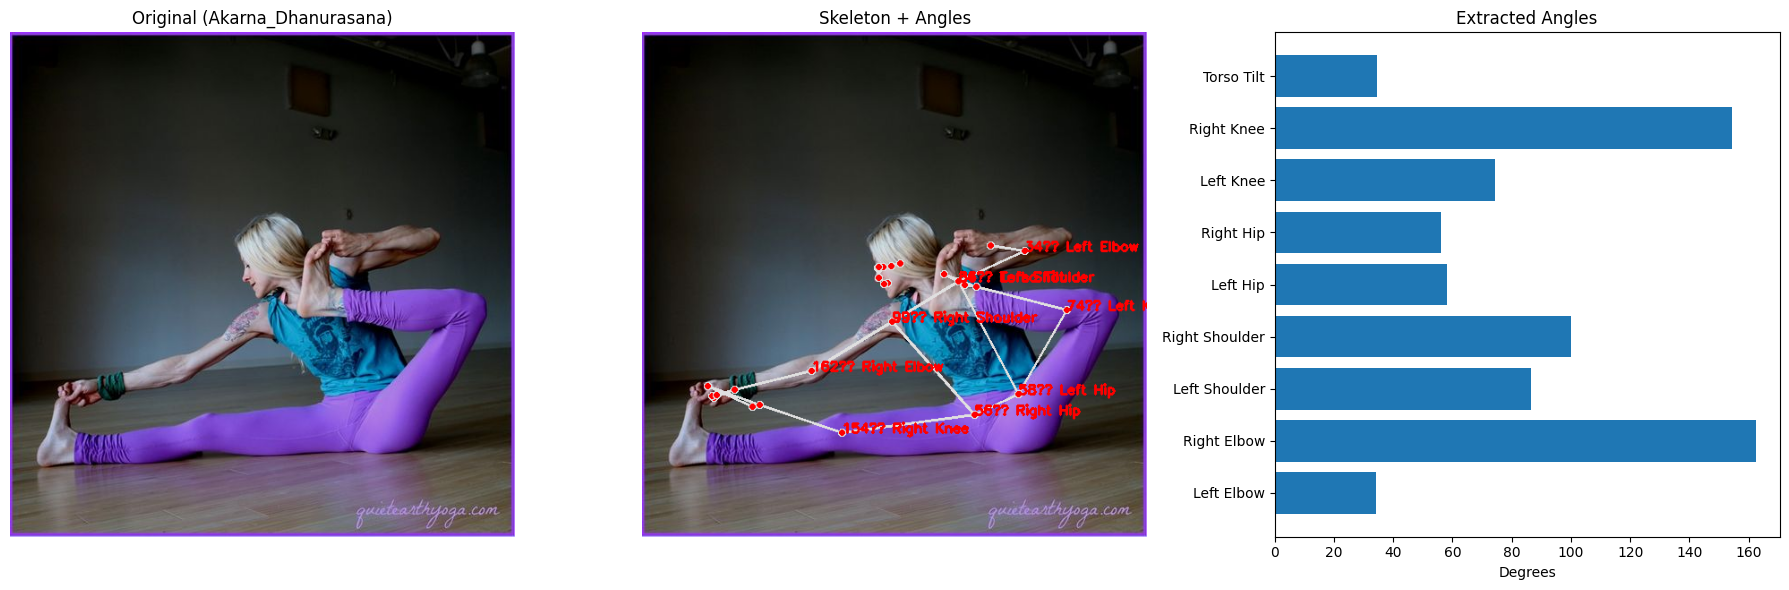

In [42]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

# --- Load processed dataset ---
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
train_meta = pd.read_csv(PROC_DIR / "metadata_train.csv")

train_npz = np.load(train_file, allow_pickle=True)
angles_all = train_npz["angles"]   # shape: (N, 9)
labels_all = train_npz["labels"]

# --- Pick a sample ---
idx = 20   # change index to see different examples
sample_angles = angles_all[idx]      # the 9 extracted angles for this image
label = labels_all[idx]
img_path = Path(train_meta.iloc[idx]["filename"])

# --- Define angle names (order must match how they were computed) ---
ANGLE_NAMES = [
    "Left Elbow", "Right Elbow",
    "Left Shoulder", "Right Shoulder",
    "Left Hip", "Right Hip",
    "Left Knee", "Right Knee",
    "Torso Tilt"
]

# --- Mediapipe setup ---
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

# --- Load image ---
image = cv2.imread(str(img_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with mp_pose.Pose(static_image_mode=True) as pose:
    results = pose.process(image_rgb)

if results.pose_landmarks:
    annotated = image.copy()
    mp_drawing.draw_landmarks(annotated, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

    h, w, _ = annotated.shape
    landmarks = results.pose_landmarks.landmark

    # --- Map joint triplets (for text placement only) ---
    JOINTS = {
        "Left Elbow": (11, 13, 15),
        "Right Elbow": (12, 14, 16),
        "Left Shoulder": (13, 11, 23),
        "Right Shoulder": (14, 12, 24),
        "Left Hip": (11, 23, 25),
        "Right Hip": (12, 24, 26),
        "Left Knee": (23, 25, 27),
        "Right Knee": (24, 26, 28),
        "Torso Tilt": (23, 11, 12)
    }

    # --- Draw each angle value on skeleton ---
    for i, name in enumerate(ANGLE_NAMES):
        angle_val = sample_angles[i]
        triplet = JOINTS[name]
        joint = triplet[1]   # middle joint for placement
        x = int(landmarks[joint].x * w)
        y = int(landmarks[joint].y * h)
        cv2.putText(
            annotated, f"{int(angle_val)}° {name}", (x, y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2
        )

    # --- Show three panels ---
    fig, axes = plt.subplots(1, 3, figsize=(18,6))

    axes[0].imshow(image_rgb)
    axes[0].set_title(f"Original ({label})")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Skeleton + Angles")
    axes[1].axis("off")

    axes[2].barh(ANGLE_NAMES, sample_angles)
    axes[2].set_title("Extracted Angles")
    axes[2].set_xlabel("Degrees")

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No pose detected in this image.")


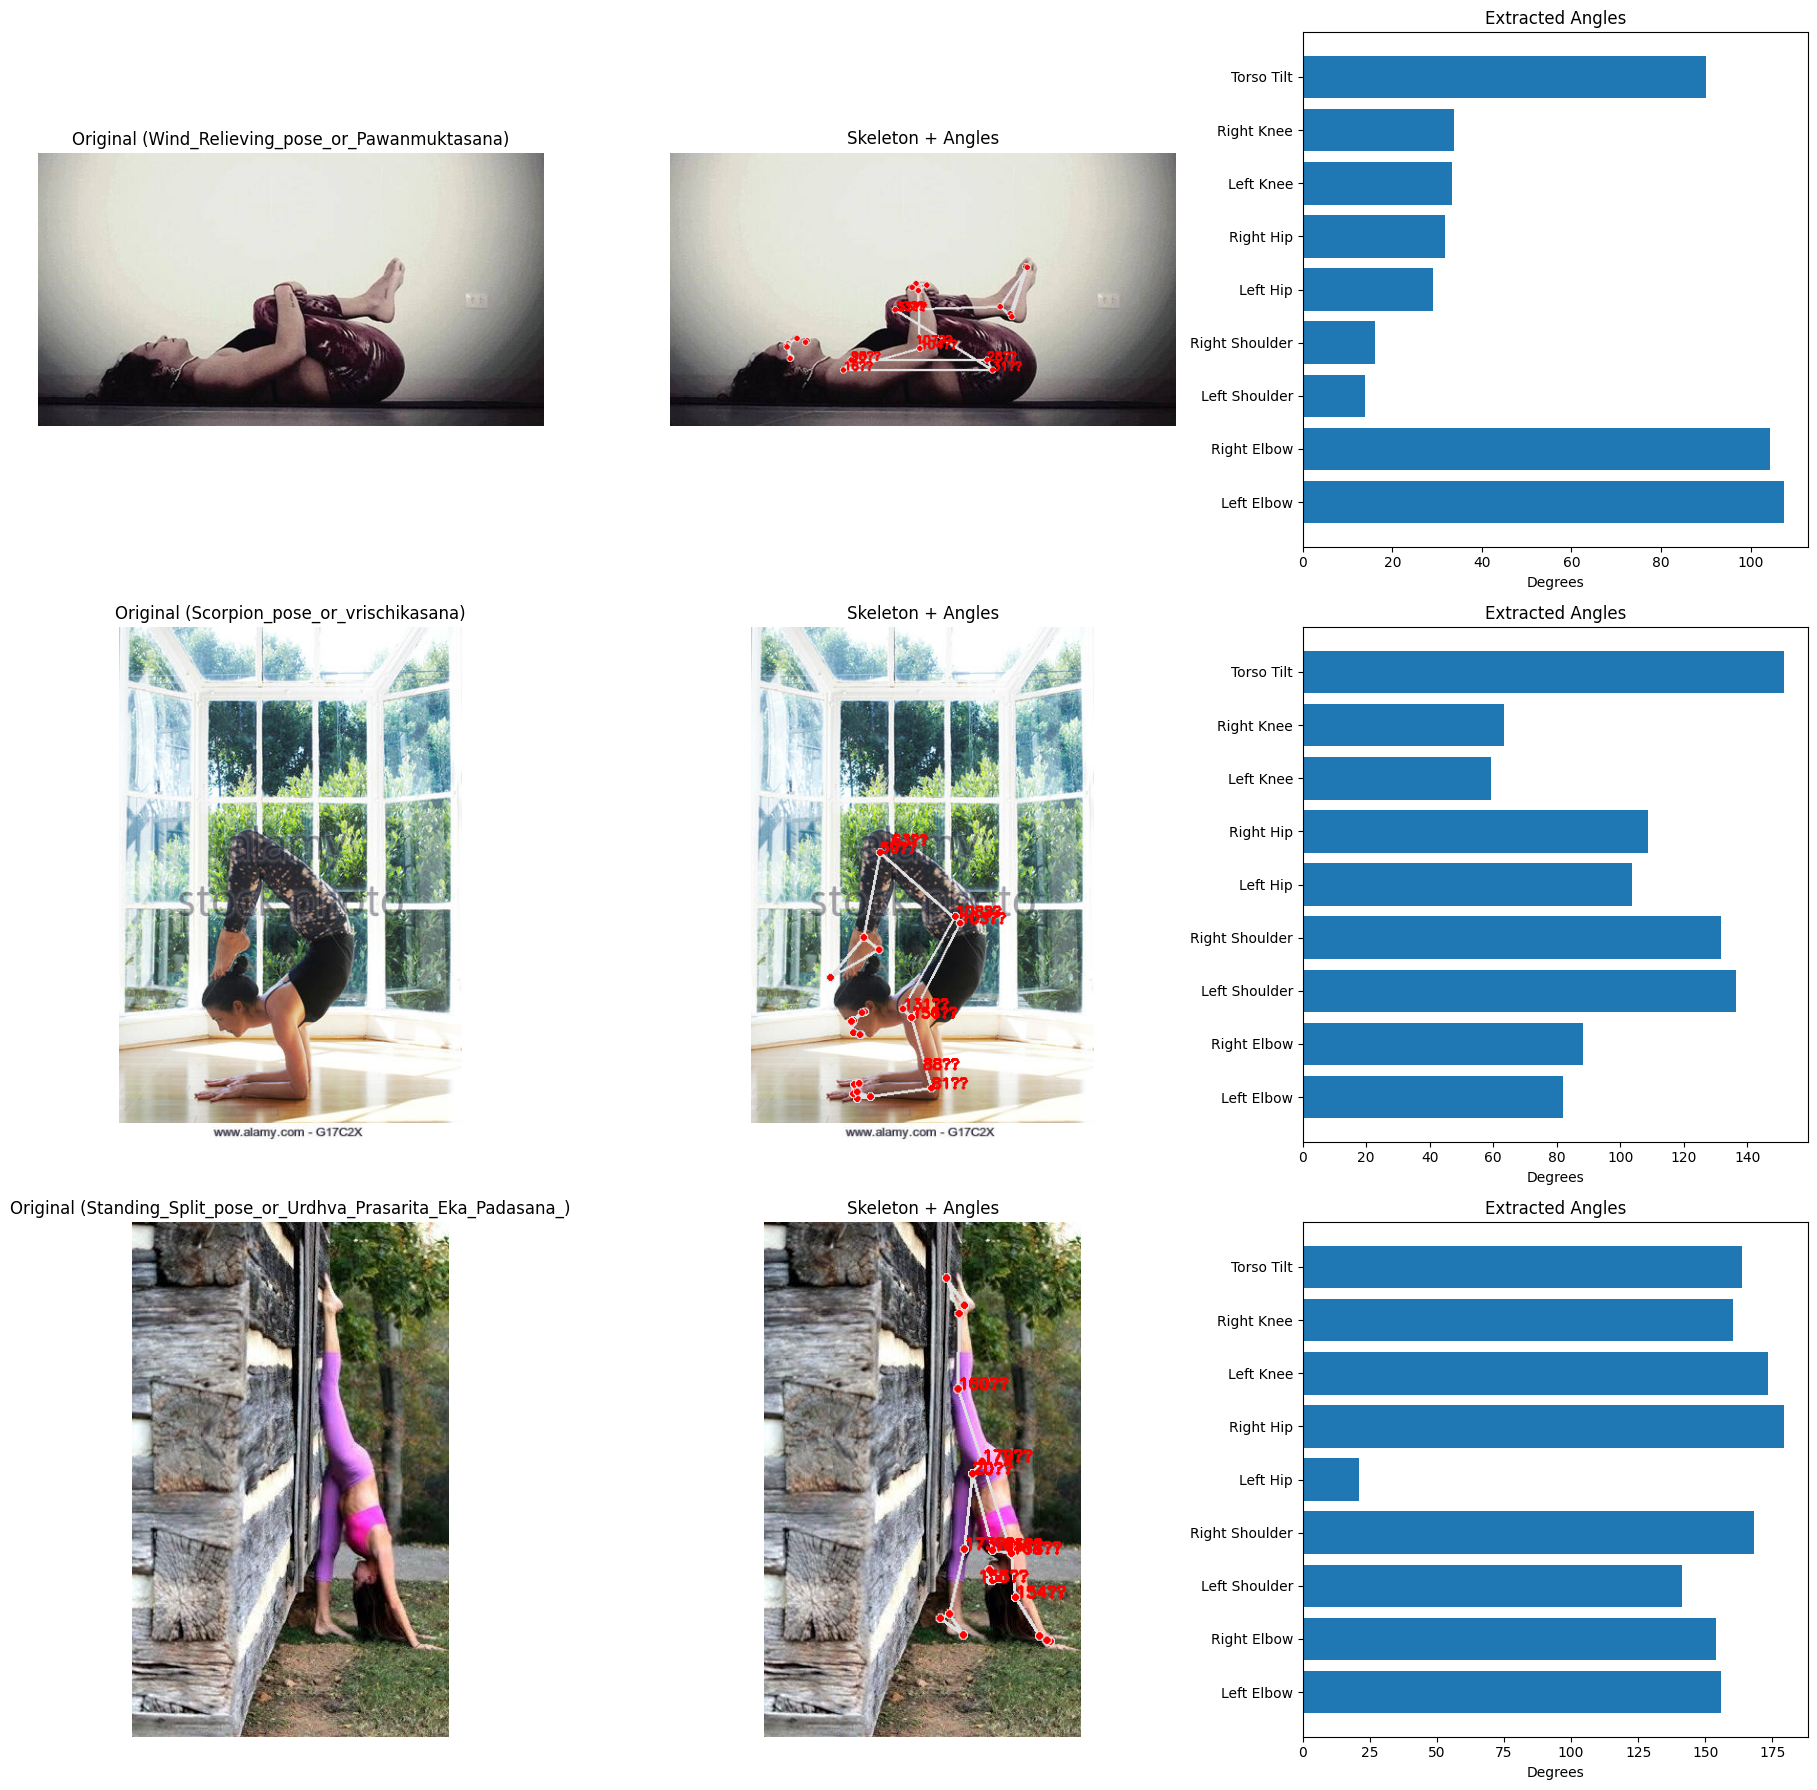

In [1]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
import random

# --- Load processed dataset ---
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
train_meta = pd.read_csv(PROC_DIR / "metadata_train.csv")

train_npz = np.load(train_file, allow_pickle=True)
angles_all = train_npz["angles"]   # shape: (N, 9)
labels_all = train_npz["labels"]

# --- Angle names (must match computation order) ---
ANGLE_NAMES = [
    "Left Elbow", "Right Elbow",
    "Left Shoulder", "Right Shoulder",
    "Left Hip", "Right Hip",
    "Left Knee", "Right Knee",
    "Torso Tilt"
]

# --- Mediapipe setup ---
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

# --- Mapping joints for annotation (central joint used for text placement) ---
JOINTS = {
    "Left Elbow": (11, 13, 15),
    "Right Elbow": (12, 14, 16),
    "Left Shoulder": (13, 11, 23),
    "Right Shoulder": (14, 12, 24),
    "Left Hip": (11, 23, 25),
    "Right Hip": (12, 24, 26),
    "Left Knee": (23, 25, 27),
    "Right Knee": (24, 26, 28),
    "Torso Tilt": (23, 11, 12)
}

# --- Function to visualize one sample ---
def visualize_sample(idx):
    sample_angles = angles_all[idx]
    label = labels_all[idx]
    img_path = Path(train_meta.iloc[idx]["filename"])

    # Load image
    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    annotated = image.copy()
    with mp_pose.Pose(static_image_mode=True) as pose:
        results = pose.process(image_rgb)
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(annotated, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

            h, w, _ = annotated.shape
            landmarks = results.pose_landmarks.landmark

            # Annotate each angle
            for i, name in enumerate(ANGLE_NAMES):
                angle_val = sample_angles[i]
                triplet = JOINTS[name]
                joint = triplet[1]
                x = int(landmarks[joint].x * w)
                y = int(landmarks[joint].y * h)
                cv2.putText(
                    annotated, f"{int(angle_val)}°", (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2
                )

    return image_rgb, annotated, sample_angles, label

# --- Show grid of N samples ---
N = 3   # number of samples to show
indices = random.sample(range(len(angles_all)), N)

fig, axes = plt.subplots(N, 3, figsize=(18, 6*N))

for row, idx in enumerate(indices):
    img_rgb, annotated, sample_angles, label = visualize_sample(idx)

    axes[row,0].imshow(img_rgb)
    axes[row,0].set_title(f"Original ({label})")
    axes[row,0].axis("off")

    axes[row,1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[row,1].set_title("Skeleton + Angles")
    axes[row,1].axis("off")

    axes[row,2].barh(ANGLE_NAMES, sample_angles)
    axes[row,2].set_title("Extracted Angles")
    axes[row,2].set_xlabel("Degrees")

plt.tight_layout()
plt.show()


Sample of extracted angle data:
   Left Elbow  Right Elbow  Left Shoulder  Right Shoulder    Left Hip  \
0  170.688141    31.149332     101.241089      107.406776   54.696690   
1  167.040100    14.495199      98.619705      126.164894   62.595222   
2  157.517822    14.952825     111.174522       88.756668   47.928936   
3  179.337067   105.858421      29.558762       23.203754  139.447540   
4   36.372066   169.851166     110.492416       93.978638   75.467804   
5   27.802124   171.536682      98.587219       24.233904   61.373379   
6   40.267277   178.855164     147.550446       87.282730   23.608660   
7   65.443352   143.671616      95.017776       91.722870   71.231590   
8  160.762115    49.326180      86.943176       53.283848   57.863476   
9   33.346989   164.361404      60.882778       11.423220   19.152054   

    Right Hip   Left Knee  Right Knee  Torso Tilt               label  
0   51.769993  165.894852   63.361053   23.452591  Akarna_Dhanurasana  
1   36.585037  156.9

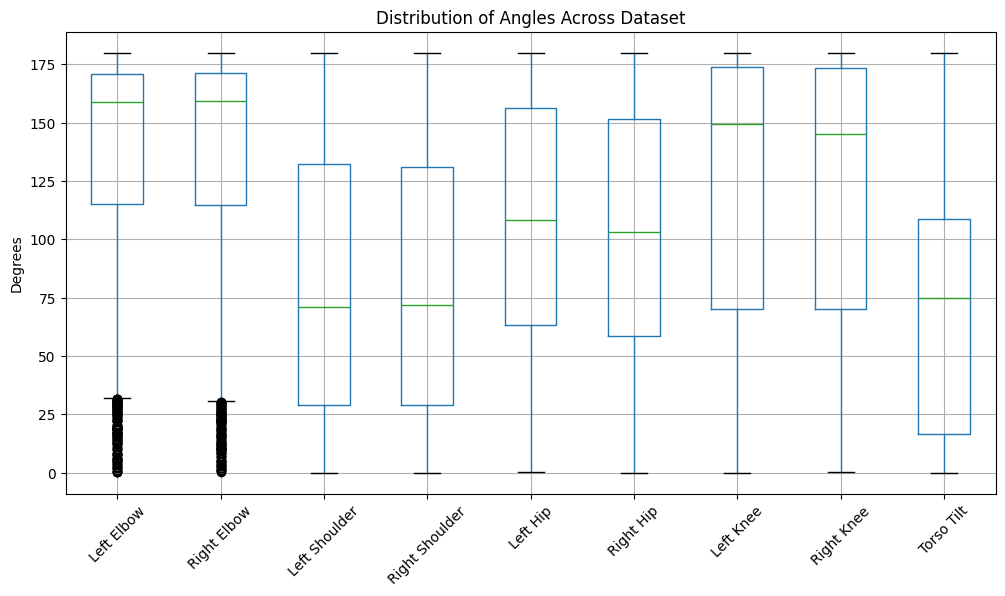

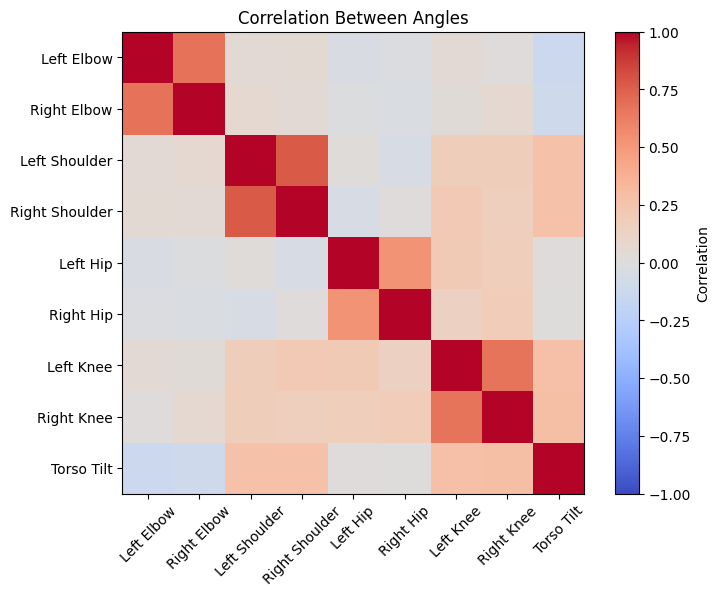


Per-class mean and std of angles:
                                             Left Elbow             \
                                                   mean        std   
label                                                                
Akarna_Dhanurasana                           109.122795  70.778816   
Bharadvajas_Twist_pose_or_Bharadvajasana_I_  160.682999  20.318205   
Boat_Pose_or_Paripurna_Navasana_             156.556351  23.981112   
Bound_Angle_Pose_or_Baddha_Konasana_         147.339188  37.074951   
Bow_Pose_or_Dhanurasana_                     159.012482  29.050879   

                                            Right Elbow             \
                                                   mean        std   
label                                                                
Akarna_Dhanurasana                           101.988335  68.514107   
Bharadvajas_Twist_pose_or_Bharadvajasana_I_  152.947693  25.707750   
Boat_Pose_or_Paripurna_Navasana_             159.75087

C:\Users\Harsh\AppData\Local\Temp\ipykernel_7696\3635748005.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


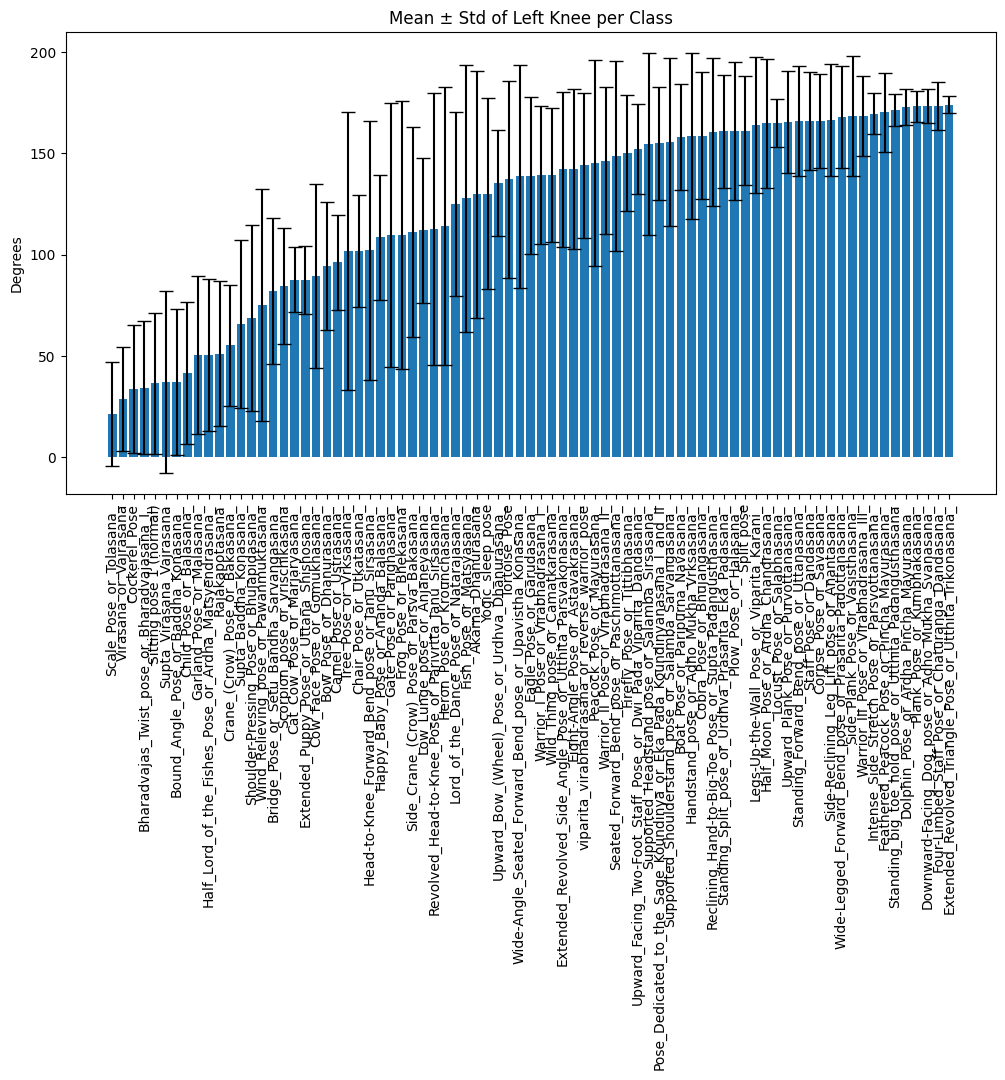

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Load processed dataset ---
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
train_npz = np.load(train_file, allow_pickle=True)

angles_all = train_npz["angles"]   # shape: (N, 9)
labels_all = train_npz["labels"]

# Angle names (must match computation order)
ANGLE_NAMES = [
    "Left Elbow", "Right Elbow",
    "Left Shoulder", "Right Shoulder",
    "Left Hip", "Right Hip",
    "Left Knee", "Right Knee",
    "Torso Tilt"
]

# --- Convert to DataFrame ---
df = pd.DataFrame(angles_all, columns=ANGLE_NAMES)
df["label"] = labels_all

# --- Show raw table (first 10 rows) ---
print("Sample of extracted angle data:")
print(df.head(10))

# --- Boxplot: distribution of each angle ---
plt.figure(figsize=(12,6))
df[ANGLE_NAMES].boxplot()
plt.title("Distribution of Angles Across Dataset")
plt.ylabel("Degrees")
plt.xticks(rotation=45)
plt.show()

# --- Correlation heatmap ---
corr = df[ANGLE_NAMES].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(ANGLE_NAMES)), ANGLE_NAMES, rotation=45)
plt.yticks(range(len(ANGLE_NAMES)), ANGLE_NAMES)
plt.title("Correlation Between Angles")
plt.show()

# --- Per-class angle statistics ---
mean_std = df.groupby("label")[ANGLE_NAMES].agg(["mean","std"])

print("\nPer-class mean and std of angles:")
print(mean_std.head())  # show first few classes

# --- Bar chart of means + std for one example angle (say Left Knee) ---
angle_to_plot = "Left Knee"
stats = df.groupby("label")[angle_to_plot].agg(["mean","std"]).sort_values("mean")

plt.figure(figsize=(12,6))
plt.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5)
plt.xticks(rotation=90)
plt.ylabel("Degrees")
plt.title(f"Mean ± Std of {angle_to_plot} per Class")
plt.tight_layout()
plt.show()
